# BCA calibration benchmark: IQL host, all seven datasets

Semi-synthetic tests of BCA's WBCP calibration banks with IQL as the host algorithm, on every
dataset BCA is configured for. The same notebook exists for each host (`results_td3_bc.ipynb`,
`results_rebrac.ipynb`, `results_cql.ipynb`, `results_iql.ipynb`), built by
`experiments/wbcp/host_notebook.py` from the matrix in `experiments/wbcp/host_matrix.py`.

**How the tests work.**
- **Score pool.** IQL with BCA's learned scale trains for 100,000 updates on half of a dataset's
  episodes (CPU, no refresh, so the host runs natively while σ(s, a) is fit). The frozen model then scores
  every transition of the other half exactly as IQL's own BCA refresh scores a held-out bank:
  residual = target − Q, score = |residual| / σ(s, a). That half is the pool.
- **Banks.** A simulated calibration bank is drawn from the pool with one of the bank designs below, and
  the test distribution is the pool itself or a tilted copy of it, so the true miscoverage of any threshold
  is known exactly.
- **Failure.** Target miscoverage α = 0.1 at credibility β = 0.95: a bank *fails* when the threshold it
  certifies misses more than 10% of test rows. A valid rule fails at most 5% of the time. Each rate is the
  share of 4,000 simulated banks that fail, with its exact 95% interval.
- **Rules.** Uniform BCA is WBCP with equal weights (BQ-CP), today's BCA calibration. WBCP uses weights
  estimated by a classifier, or the exact weights. RCPS is a conservative frequentist baseline.
- **Bank size.** IQL's configured bank: n and K per dataset from `configs/iql.yaml`.

**Bank designs** (no shift unless stated):

| Design | What it is | Why it is here |
|---|---|---|
| Independent rows | n rows drawn independently | the reference: should fail about 5% |
| K = 2, 5, 10 spaced | K rows from each episode, one per K-th of it | how failure grows with rows per episode |
| Whole episodes | BCA's original bank | the dependence stress test |
| Configured, BCA sampler | K rows per episode with BCA's own reservation (`calibration/bank.py`) | what IQL + BCA deploys |
| Configured, spaced | the same K with the spaced sampler | the other side of the finite-pool bracket |
| Independent rows, large bank | 8,192 rows (1,194 on pen-human) | estimated against exact weights |
| K = 5 spaced, six tilts | policy, density and state tilts at γ = 0.5 and 1 | distribution shift |

**Expectations** were written before the runs (Stage A before the pools, Stage B with the Monte Carlo
predictions before any benchmark run) and are shown in full in section 2 with their SHA-256.

In [1]:
import math
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "runs").is_dir() and (p / "calibration").is_dir())
sys.path.insert(0, str(ROOT))
from experiments.wbcp.host_matrix import DATASETS, HOSTS, TILTS, load_results

HOST = "iql"
R = load_results(HOST)
pd.set_option("display.max_rows", 500, "display.max_columns", 40, "display.width", 250, "display.max_colwidth", 70)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9.5, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True, "legend.frameon": False,
                     "legend.fontsize": 8.5, "axes.titlesize": 10.5})
ARMS = {"BQ-CP": "Uniform BCA", "WBCP": "WBCP, estimated weights", "WBCP (oracle w)": "WBCP, exact weights", "RCPS": "RCPS"}
COL = {"BQ-CP": "#b8701a", "WBCP": "#0d8a96", "WBCP (oracle w)": "#0b4f58", "RCPS": "#7d889b", "pred": "#4b5fc1", "target": "#c0392b"}
SHORT = {"hopper": "hopper-medium", "walker2d": "walker2d-medium-replay", "halfcheetah": "halfcheetah-medium-expert",
         "maze2d": "maze2d-large", "pen-cloned": "pen-cloned", "pen-expert": "pen-expert", "pen-human": "pen-human"}
SCORES = ("normalized", "raw")


def P(d):
    return d.replace("-", "")


# the no-shift designs, as (column label, run-name suffix for a dataset entry, dependence.py design label)
def designs(e):
    k = e["k"]
    rows = [("Independent rows", "iid", None), ("K=2 spaced", "strat2", "2 per episode, stratified"),
            ("K=5 spaced", "strat5", "5 per episode, stratified"), ("K=10 spaced", "strat10", "10 per episode, stratified"),
            ("Configured K, spaced", f"strat{k}", f"{k} per episode, stratified"),
            ("Configured K, BCA sampler", f"resv{k}", f"{k} per episode, BCA reservation"),
            ("Whole episodes", "blocks", "whole episodes")]
    if e["n"] < e["big"]:
        rows.append(("Independent rows, large bank", "iid_big", None))
    return rows


COLUMNS = ["Independent rows", "K=2 spaced", "K=5 spaced", "K=10 spaced", "Configured K, spaced", "Configured K, BCA sampler",
           "Whole episodes", "Independent rows, large bank"]


def block(d, suffix, t="policy", y=0.0, s="normalized"):
    run = R["datasets"][d]["runs"].get(f"{P(d)}_{suffix}")
    if run is None:
        return None
    return next((b for b in run["blocks"] if b["t"] == t and b["y"] == y and b["s"] == s), None)


def arm(d, suffix, a="BQ-CP", t="policy", y=0.0, s="normalized"):
    b = block(d, suffix, t, y, s)
    return None if b is None else b["A"].get(a)


def pct(a):
    return np.nan if a is None else 100 * a["f"] / a["T"]


def fmt(a):
    # failures / trials rounded half-up to one decimal, as in DEPENDENCE.md
    return "–" if a is None else f"{((2000 * a['f'] + a['T']) // (2 * a['T'])) / 10:.1f}"


def fail(a):
    return "–" if a is None else f"{fmt(a)}% [{100 * a['lo']:.1f}, {100 * a['hi']:.1f}]"


def yerr(arms):
    return [[pct(a) - 100 * a["lo"] if a else 0 for a in arms], [100 * a["hi"] - pct(a) if a else 0 for a in arms]]


def prediction(d, label, s="normalized"):
    # (predicted failure in %, Monte Carlo design effect) from dependence.py; independent rows: 5% and D = 1
    e = R["datasets"][d]
    if label is None:
        return 5.0, 1.0
    if e["pred"] is None:
        return np.nan, np.nan
    for x in e["pred"]["scores"][s]["designs"]:
        if x["design"] == label and x["n"] == e["n"]:
            return (np.nan if x["pmc"] is None else 100 * x["pmc"]), x["Dmc"]
    return np.nan, np.nan


def verdict(obs, pred, D):
    # Stage B tolerance: within about 2 points of the prediction, 5 where the design effect exceeds 3
    if np.isnan(obs) or np.isnan(pred):
        return "–"
    tol = 5 if (D is not None and D > 3) else 2
    return "met" if abs(obs - pred) <= tol else ("missed (higher)" if obs > pred else "missed (lower)")


def target(ax, y=5, label="5% target"):
    ax.axhline(y, color=COL["target"], ls="--", lw=1)
    ax.annotate(label, xy=(1, y), xycoords=("axes fraction", "data"), ha="right", va="bottom", color=COL["target"], fontsize=8)


def table(rows, columns):
    return pd.DataFrame(rows, columns=columns)


# a pool whose critic diverged or was still growing is flagged everywhere with a warning sign
FLAG = {d: R["datasets"][d]["pool"]["health"]["status"] for d in DATASETS
        if R["datasets"][d]["pool"] and R["datasets"][d]["pool"]["health"] and R["datasets"][d]["pool"]["health"]["status"] != "ok"}
for d in FLAG:
    SHORT[d] += " ⚠"
if FLAG:
    display(Markdown("**⚠ Critic not converged:** " + "; ".join(f"{SHORT[d]} ({s})" for d, s in FLAG.items())
                     + ". Their calibration results are exact for those scores, but a diverging critic's residuals do not "
                       "represent a trained " + R["name"] + " critic, so they are left out of conclusions about dependence."))
have = [d for d in DATASETS if R["datasets"][d]["pool"]]
runs = sum(len(R["datasets"][d]["runs"]) for d in DATASETS)
missing = sum(len(R["datasets"][d]["missing"]) for d in DATASETS)
print(f"{R['name']}: {len(have)}/7 score pools, {runs} benchmark runs loaded, {missing} not run yet (results root {R['root']})")

IQL: 7/7 score pools, 55 benchmark runs loaded, 0 not run yet (results root runs/wbcp_hosts/iql)


## 1. Score pools and within-episode dependence

One pool per dataset: the withheld half of its episodes, scored by the frozen IQL model. ρ is the
intra-episode correlation of misses at the true threshold λ\* (the indicator score > λ\*), for the
normalized score with the raw score in brackets. It drives everything below: a bank with m rows per episode
has its variance inflated by the design effect D ≈ 1 + (m − 1)ρ, and its failure rate rises to about
1 − Φ(1.645 / √D). The lag correlations show how fast dependence decays along an episode.

,Dataset,Pool rows,Pool episodes,Training rows,Updates,Bank n,K,Episodes in bank,λ* (normalized),ρ normalized (raw),Lag-1 corr.,Lag-50 corr.,Critic,"Q growth, last 20%",Scores ≤ 1
0,hopper-medium,500285,1094,499713,100000,8192,17,482,0.796,0.012 (0.019),0.283,-0.022,ok,None,0.968
1,walker2d-medium-replay,151195,528,150503,100000,8192,67,123,0.871,0.050 (0.073),0.273,0.051,ok,None,0.931
2,halfcheetah-medium-expert,999000,1000,999000,100000,8192,17,482,0.734,0.018 (0.027),0.081,0.020,ok,None,0.961
3,maze2d-large,1992027,8168,1991246,100000,8192,5,1639,0.522,0.050 (0.128),0.496,0.047,ok,None,0.986
4,pen-cloned,248165,1887,248099,100000,8192,11,745,0.953,0.213 (0.226),0.607,0.152,ok,None,0.910
5,pen-expert,247146,2501,247102,100000,8192,7,1171,0.806,0.064 (0.120),0.254,0.039,ok,None,0.945
6,pen-human,2587,13,2388,100000,1194,199,6,36.969,0.388 (0.300),0.920,0.255,ok,None,0.082


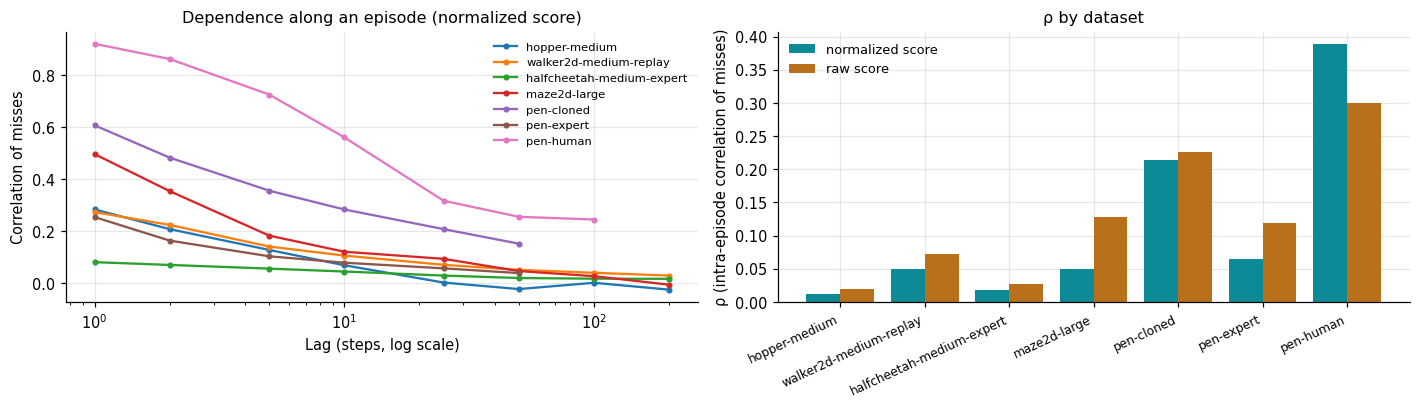

In [2]:
rows = []
for d in DATASETS:
    e = R["datasets"][d]
    p, q = e["pool"], e["pred"]
    if p is None:
        rows.append([SHORT[d], "pool not built yet"] + [None] * 13)
        continue
    sn, sr = (q["scores"]["normalized"], q["scores"]["raw"]) if q else (None, None)
    lag = lambda k: None if sn is None or sn["lags"].get(k) is None else round(sn["lags"][k], 3)
    h = p["health"] or {}
    rows.append([SHORT[d], p["rows"]["population"], p["rows"]["population_episodes"], p["rows"]["training"], p["updates"],
                 e["n"], e["k"], math.ceil(e["n"] / e["k"]), None if sn is None else round(sn["lambda_star"], 3),
                 None if sn is None else f"{sn['rho']:.3f} ({sr['rho']:.3f})", lag("1"), lag("50"),
                 h.get("status", "–"), None if h.get("q_growth_last_fifth") is None else f"{100 * h['q_growth_last_fifth']:+.0f}%",
                 None if p["frac_score_le_1"] is None else round(p["frac_score_le_1"], 3)])
display(table(rows, ["Dataset", "Pool rows", "Pool episodes", "Training rows", "Updates", "Bank n", "K", "Episodes in bank",
                     "λ* (normalized)", "ρ normalized (raw)", "Lag-1 corr.", "Lag-50 corr.", "Critic", "Q growth, last 20%",
                     "Scores ≤ 1"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for d in DATASETS:
    q = R["datasets"][d]["pred"]
    if q is None:
        continue
    lags = {int(k): v for k, v in q["scores"]["normalized"]["lags"].items() if v is not None}
    axes[0].plot(list(lags), list(lags.values()), marker="o", ms=3, label=SHORT[d])
axes[0].set_xscale("log"); axes[0].set_xlabel("Lag (steps, log scale)"); axes[0].set_ylabel("Correlation of misses")
axes[0].set_title("Dependence along an episode (normalized score)"); axes[0].legend(fontsize=7.5)
x = np.arange(len(DATASETS))
for i, s in enumerate(SCORES):
    vals = [np.nan if R["datasets"][d]["pred"] is None else R["datasets"][d]["pred"]["scores"][s]["rho"] for d in DATASETS]
    axes[1].bar(x - 0.2 + 0.4 * i, vals, 0.4, label=f"{s} score", color=["#0d8a96", "#b8701a"][i])
axes[1].set_xticks(x, [SHORT[d] for d in DATASETS], rotation=25, ha="right", fontsize=8)
axes[1].set_ylabel("ρ (intra-episode correlation of misses)"); axes[1].set_title("ρ by dataset"); axes[1].legend()
plt.tight_layout(); plt.show()

## 2. Pre-registered expectations

The expectation file is shown verbatim. It was written before the runs it concerns: Stage A before the score
pools existed, Stage B (the Monte Carlo predictions) after the pools and before any benchmark run. Its
SHA-256 identifies this exact text.

In [3]:
for x in R["expectations"]:
    display(Markdown(f"`{x['file']}`, SHA-256 `{x['sha']}`"))
    display(Markdown("> " + x["text"].replace("\n", "\n> ")))
if not R["expectations"]:
    print("no expectation file yet")

`runs/wbcp_hosts/iql/expectations.md`, SHA-256 `0c11e9f784cdc542731191e66b303e6c59ba9b7acb10e4793a4ca27df9c3ec10`

> # Pre-registered expectations: IQL host, dependence on all seven datasets (2026-10-01T17:22:18Z)
> 
> Written before any IQL score pool exists (no IQL pool has been built; the only IQL
> scores so far are 2,000-update smoke tests of the new pool builder on hopper, used to check the code,
> not looked at for dependence). Same recipe as TD3+BC (Change 12): the host trains for 100,000 updates
> on half of each dataset's episodes (seed 202609171, split seed 202609171), and the frozen model scores
> every row of the other half the way IQL's own BCA refresh scores a held-out bank. The matrix of runs
> is `experiments/wbcp/host_matrix.py --host iql`; the bank of each dataset is IQL's configured one
> (configs/iql.yaml).
> 
> Reference (TD3+BC pools, normalized score): rho = hopper 0.016, walker2d-medium-replay 0.120,
> halfcheetah-medium-expert 0.033, maze2d-large 0.073, pen-cloned 0.108, pen-expert 0.054, pen-human 0.090.
> 
> ## Stage A (now, before the pools)
> 
> Common to every host:
> 1. **rho is mostly a property of the dataset.** The rank order of the seven datasets by rho under IQL
>    agrees with TD3+BC's (Spearman correlation at least 0.7), hopper is the lowest or second lowest, and
>    IQL's rho is within a factor of 2 of TD3+BC's on at least 5 of the 7 datasets. Reason: the
>    episode structure (which policies made the data, how smooth the trajectories are) is shared; the host
>    changes the residual's noise and bias but not that structure.
> 2. **Independent rows fail 4-6%** for uniform BCA on every dataset (no dependence, so no host effect).
> 3. **Whole-episode banks fail more than 20%** on every dataset.
> 4. **Configured banks** follow D = 1 + (K - 1) rho. With rho anywhere from half to twice TD3+BC's, the
>    normal approximation 1 - Phi(1.645 / sqrt(D)) gives:
>    - hopper K=17: 6.1-9.0%; halfcheetah K=17: 7.2-12.6%; maze2d K=5: 6.2-9.6%;
>      pen-cloned K=11: 9.2-17.7%; pen-expert K=7: 6.4-10.0%;
>      walker2d K=67: 23-34%; pen-human K=199: 30-39%.
>    - IQL's banks hold 8,192 rows (1,194 on pen-human), so its configured K is the largest of the four
>      hosts on five datasets and its configured banks should fail the most.
>    The Stage B Monte Carlo predictions on the real pools replace these ranges before any benchmark run.
> 5. **Shift (K = 5 spaced, six tilts):** uniform BCA fails far above 5% under the density and state tilts
>    on every dataset; WBCP fails more than 5% at the strongest aligned tilts (Change 11's finite-sample
>    effect plus dependence) but far less than uniform BCA.
> 6. **Estimated weights at the large bank:** WBCP with estimated (flat-in-truth) weights fails more than the
>    uniform rule where the score is not locally adaptive; at least on walker2d and pen-cloned, as with
>    TD3+BC (Change 10).
> 7. **pen-human** has about 13 episodes in its pool, so every estimate there is noisy, and its spaced K = 2
>    and K = 5 predictions can fall below 5% (finite-pool artifacts).
> 
> Specific to IQL:
> 8. IQL's target is r + gamma V(s'), learned in-sample, with no target-policy noise. The row-level noise
>    in the residual is therefore smaller than TD3+BC's, and the smooth, episode-level part makes up more of
>    it, so expect rho at or above TD3+BC's on most datasets (at least 4 of 7; direction stated, low
>    confidence).
> 
> ## Addendum (2026-10-01T19:36:32Z): the IQL score changes before Stage B
> 
> BCA's IQL calibration is being aligned with what IQL's actor reads (branch critic-alignment, ordered by
> the user). The actor's advantage weights read min over the Polyak **target** Q heads minus V, while the old
> refresh calibrated min over the **online** heads. The pools trained so far
> (hopper, walker2d, halfcheetah, maze2d, pen-cloned) were scored the old way. Training does not depend on
> the scoring, and each pool's checkpoint holds the target heads. So every IQL pool will be rescored with
> the aligned residual, r + gamma (1 - d) V(s') - min_k Q_target_k(s, a), before any prediction or benchmark.
> Nothing about IQL's dependence has been looked at: so far only the critic-health check (mean Q, Q growth,
> share of scores at most 1) has been read. The Stage A expectations above are unchanged and apply to the
> aligned score.
> 
> Correction (2026-10-01T19:39:47Z): rescoring is not enough. IQL's scale network is fit during training through the same
> calibration inputs (calibration/iql_scale.py calls adapter.calibration_inputs), so aligned IQL pools are
> **retrained** with the aligned code once it is on main. The host's critic, value and actor do not depend on
> the scale fit and come out the same. The pre-alignment pools are kept as the before-fix record. The
> in-progress pen-expert pool was stopped and its empty directory removed.
> 
> ## Stage B (2026-10-02T03:11:26Z): after the retrained pools, before any benchmark run
> 
> The pools were retrained on CPU with the target-head fix on main (fdba570), 100,000 updates each. The score is
> r + gamma (1 - d) V(s') - min_k Q_target_k(s, a). Every pool has the same withheld episodes as the other hosts.
> Predictions use the trimmed samplers.
> 
> **Critic health:** all seven pools are inside their possible Q range (IQL logs no Q series, so only the loss ratio
> and the range check apply). The three pen critics are healthy; TD3+BC's and CQL's were not.
> - pen-human's scale network under-covers badly: only 8% of scores are at most 1, against a target of 0.9. That is
>   reported, not judged; calibration stays valid for any fixed score.
> 
> Monte Carlo predictions (uniform BCA, no shift; normalized score, raw in brackets):
> 
> | Dataset (n, K) | rho | K=2 spaced | K=5 spaced | K=10 spaced | Configured K, spaced | Configured K, BCA sampler | Whole episodes |
> |---|---|---|---|---|---|---|---|
> | hopper (n=8192, K=17) | 0.012 (0.019) | 5.2% (5.2%) | 5.3% (5.4%) | 5.4% (5.8%) | 5.8% (6.6%) | 5.3% (5.6%) | 23.2% (27.1%) |
> | walker2d (n=8192, K=67) | 0.050 (0.073) | 5.3% (5.4%) | 6.3% (6.7%) | 7.8% (9.2%) | 20.8% (24.4%) | 16.1% (19.7%) | 36.5% (37.8%) |
> | halfcheetah (n=8192, K=17) | 0.018 (0.027) | 5.1% (5.1%) | 5.4% (5.9%) | 6.2% (6.6%) | 7.1% (8.2%) | 6.0% (6.3%) | 35.2% (37.8%) |
> | maze2d (n=8192, K=5) | 0.050 (0.128) | 5.1% (5.2%) | 5.9% (7.7%) | 7.4% (11.9%) | 5.9% (7.7%) | 5.6% (6.8%) | 32.6% (38.8%) |
> | pen-cloned (n=8192, K=11) | 0.213 (0.226) | 6.2% (6.3%) | 10.3% (10.8%) | 16.0% (16.6%) | 16.7% (17.2%) | 12.7% (13.0%) | 37.4% (37.8%) |
> | pen-expert (n=8192, K=7) | 0.064 (0.120) | 5.5% (5.8%) | 6.7% (8.4%) | 9.1% (11.9%) | 7.9% (9.8%) | 5.8% (6.8%) | 26.9% (31.9%) |
> | pen-human (n=1194, K=199) | 0.388 (0.300) | 7.3% (6.8%) | 13.8% (12.1%) | 20.7% (18.0%) | 42.4% (41.3%) | 40.1% (38.7%) | 42.5% (41.4%) |
> 
> **Stage A check** (normalized rho; TD3+BC reference in Stage A above):
> 1. **Rank order: not met.** Spearman correlation about 0.63 (ties at walker2d and maze2d) against the required
>    0.7. hopper is the lowest (met). Within a factor of 2 of TD3+BC on 5 of 7 datasets (met): walker2d is 0.42x and
>    pen-human 4.3x.
> 2. **The specific prediction, rho at or above TD3+BC's on at least 4 of 7: not met** (3 of 7: pen-cloned,
>    pen-expert, pen-human). It is lower on hopper, walker2d, halfcheetah and maze2d (walker2d 0.050 vs 0.120).
> 3. **Configured banks: mostly not met.** The predicted failures fall below the Stage A ranges on five datasets
>    (hopper, walker2d, halfcheetah, maze2d, pen-expert), because rho is lower. pen-cloned is inside its range;
>    pen-human (40.1%) is above.
> 
> Expectations for the benchmark runs (4,000 trials each, both scores):
> 1. **Within tolerance.** Every no-shift design lands within about ±2 points of its Monte Carlo prediction, or ±5
>    where D > 3. Banks of 1-2 episodes (whole episodes; pen-human K = 199 with 6 of 13 episodes) may miss beyond
>    that, as on every other host.
> 2. **Independent rows** land at 4-6% at n = 8,192.
> 3. **Shift and the large bank:** as in Stage A, items 5-6. IQL's bank is already the large bank.
> 

## 3. Findings

No written interpretation yet: the sections below show every result against its pre-registered expectation. The interpretation is added to `experiments/wbcp/host_findings/iql.md` once the matrix is complete.

## 4. Failure by bank design, no shift

Uniform BCA's failure rate for every design on every dataset (normalized score). Without shift every
weight is 1, so uniform BCA and WBCP with exact weights are the same rule; WBCP with estimated weights
differs only by the noise of fitting the weights. Cells read failure (%); the 5% target is the line between
blue and red.

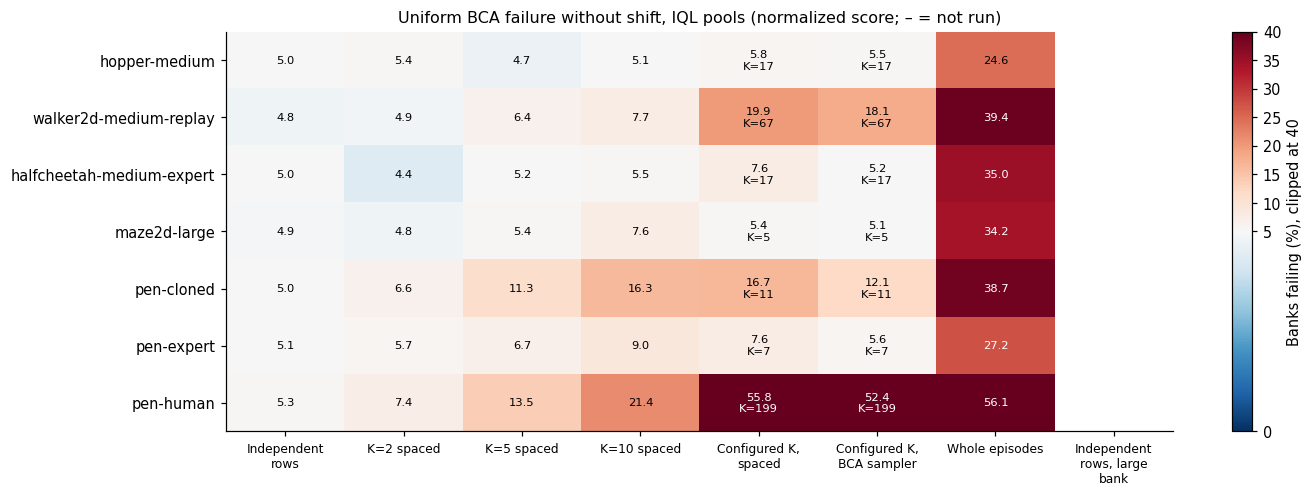

**Uniform BCA, normalized score: failure % [95% interval]**

,Dataset,Bank n,Independent rows,K=2 spaced,K=5 spaced,K=10 spaced,"Configured K, spaced","Configured K, BCA sampler",Whole episodes,"Independent rows, large bank"
0,hopper-medium,8192,"5.0% [4.3, 5.7]","5.4% [4.7, 6.2]","4.7% [4.1, 5.4]","5.1% [4.5, 5.9]","5.8% [5.0, 6.5] (K=17)","5.5% [4.8, 6.3] (K=17)","24.6% [23.2, 25.9]",n/a
1,walker2d-medium-replay,8192,"4.8% [4.2, 5.5]","4.9% [4.2, 5.6]","6.4% [5.7, 7.2]","7.7% [6.9, 8.6]","19.9% [18.7, 21.2] (K=67)","18.1% [16.9, 19.3] (K=67)","39.4% [37.9, 40.9]",n/a
2,halfcheetah-medium-expert,8192,"5.0% [4.3, 5.7]","4.4% [3.7, 5.0]","5.2% [4.5, 5.9]","5.5% [4.8, 6.3]","7.6% [6.8, 8.5] (K=17)","5.2% [4.5, 5.9] (K=17)","35.0% [33.5, 36.5]",n/a
3,maze2d-large,8192,"4.9% [4.3, 5.6]","4.8% [4.2, 5.5]","5.4% [4.7, 6.1]","7.6% [6.8, 8.5]","5.4% [4.7, 6.1] (K=5)","5.1% [4.4, 5.8] (K=5)","34.2% [32.7, 35.6]",n/a
4,pen-cloned,8192,"5.0% [4.3, 5.7]","6.6% [5.8, 7.4]","11.3% [10.3, 12.3]","16.3% [15.1, 17.4]","16.7% [15.5, 17.9] (K=11)","12.1% [11.1, 13.2] (K=11)","38.7% [37.1, 40.2]",n/a
5,pen-expert,8192,"5.1% [4.4, 5.8]","5.7% [5.0, 6.4]","6.7% [5.9, 7.5]","9.0% [8.1, 9.9]","7.6% [6.7, 8.4] (K=7)","5.6% [4.9, 6.3] (K=7)","27.2% [25.8, 28.6]",n/a
6,pen-human,1194,"5.3% [4.6, 6.1]","7.4% [6.6, 8.3]","13.5% [12.5, 14.6]","21.4% [20.2, 22.7]","55.8% [54.2, 57.3] (K=199)","52.4% [50.8, 54.0] (K=199)","56.1% [54.6, 57.7]",n/a


**Uniform BCA, raw score: failure % [95% interval]**

,Dataset,Bank n,Independent rows,K=2 spaced,K=5 spaced,K=10 spaced,"Configured K, spaced","Configured K, BCA sampler",Whole episodes,"Independent rows, large bank"
0,hopper-medium,8192,"5.4% [4.7, 6.2]","5.2% [4.5, 5.9]","4.9% [4.3, 5.6]","5.5% [4.8, 6.2]","7.0% [6.3, 7.9] (K=17)","5.4% [4.7, 6.1] (K=17)","29.0% [27.6, 30.4]",n/a
1,walker2d-medium-replay,8192,"5.0% [4.3, 5.7]","4.5% [3.9, 5.2]","6.4% [5.7, 7.2]","8.8% [7.9, 9.7]","23.7% [22.4, 25.0] (K=67)","25.1% [23.7, 26.4] (K=67)","40.2% [38.7, 41.7]",n/a
2,halfcheetah-medium-expert,8192,"5.3% [4.6, 6.0]","4.7% [4.1, 5.4]","5.8% [5.0, 6.5]","6.7% [6.0, 7.5]","8.2% [7.4, 9.1] (K=17)","5.7% [5.0, 6.4] (K=17)","40.4% [38.8, 41.9]",n/a
3,maze2d-large,8192,"5.1% [4.4, 5.8]","5.1% [4.4, 5.8]","7.8% [7.0, 8.7]","12.6% [11.6, 13.6]","7.8% [7.0, 8.7] (K=5)","6.0% [5.3, 6.8] (K=5)","40.5% [38.9, 42.0]",n/a
4,pen-cloned,8192,"4.7% [4.1, 5.4]","6.6% [5.8, 7.4]","10.9% [9.9, 11.9]","16.7% [15.6, 17.9]","18.0% [16.8, 19.2] (K=11)","13.1% [12.1, 14.2] (K=11)","39.3% [37.8, 40.8]",n/a
5,pen-expert,8192,"5.8% [5.1, 6.5]","6.3% [5.6, 7.1]","8.0% [7.2, 8.9]","11.5% [10.5, 12.5]","9.9% [8.9, 10.8] (K=7)","5.9% [5.2, 6.7] (K=7)","32.9% [31.5, 34.4]",n/a
6,pen-human,1194,"4.4% [3.8, 5.1]","6.7% [5.9, 7.5]","12.2% [11.2, 13.3]","18.7% [17.5, 19.9]","47.8% [46.3, 49.4] (K=199)","41.1% [39.6, 42.6] (K=199)","46.9% [45.3, 48.4]",n/a


In [4]:
cols = COLUMNS
mat = np.full((len(DATASETS), len(cols)), np.nan)
ann = [["" for _ in cols] for _ in DATASETS]
for i, d in enumerate(DATASETS):
    e = R["datasets"][d]
    for label, suffix, _ in designs(e):
        j = cols.index(label)
        a = arm(d, suffix)
        mat[i, j] = pct(a)
        k = e["k"] if "Configured" in label else None
        ann[i][j] = ("–" if a is None else fmt(a)) + (f"\nK={k}" if k else "")
fig, ax = plt.subplots(figsize=(13, 4.6))
from matplotlib.colors import TwoSlopeNorm
im = ax.imshow(np.clip(mat, 0, 40), cmap="RdBu_r", norm=TwoSlopeNorm(vmin=0, vcenter=5, vmax=40), aspect="auto")
for i in range(len(DATASETS)):
    for j in range(len(cols)):
        ax.text(j, i, ann[i][j], ha="center", va="center", fontsize=7.5, color="white" if (not np.isnan(mat[i, j]) and mat[i, j] > 25) else "black")
ax.set_xticks(range(len(cols)), [textwrap.fill(c, 14) for c in cols], fontsize=8); ax.set_yticks(range(len(DATASETS)), [SHORT[d] for d in DATASETS])
ax.grid(False); plt.colorbar(im, ax=ax, label="Banks failing (%), clipped at 40")
ax.set_title(f"Uniform BCA failure without shift, {R['name']} pools (normalized score; – = not run)")
plt.tight_layout(); plt.show()

for s in SCORES:
    rows = []
    for d in DATASETS:
        e = R["datasets"][d]
        cells = {label: fail(arm(d, suffix, s=s)) + (f" (K={e['k']})" if "Configured" in label else "") for label, suffix, _ in designs(e)}
        rows.append([SHORT[d], e["n"]] + [cells.get(c, "n/a") for c in cols])
    display(Markdown(f"**Uniform BCA, {s} score: failure % [95% interval]**"))
    display(table(rows, ["Dataset", "Bank n"] + cols))

## 5. Predictions against results

Each no-shift design's observed failure against its Stage B Monte Carlo prediction (dependence.py, the
same sampler on the same pool). Independent rows are predicted at 5%. The pre-registered tolerance is about
±2 points, or ±5 where the design effect exceeds 3.

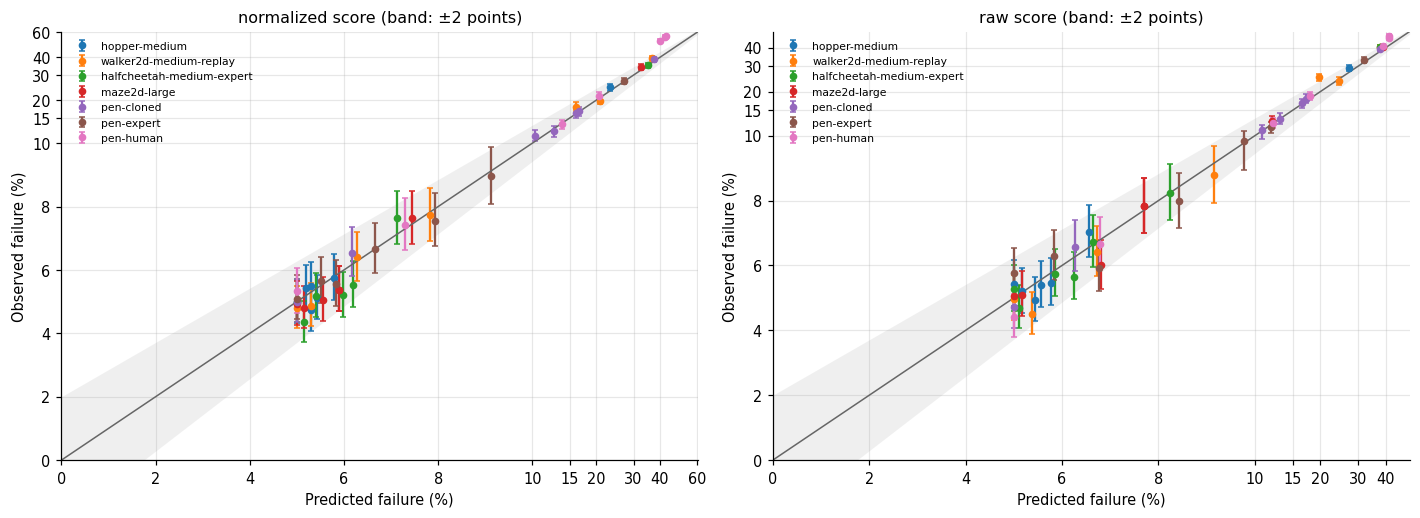

**Scorecard:** 92 met, 6 missed (higher)

,Dataset,Design,Score,Predicted (%),D (Monte Carlo),Observed,Verdict
0,hopper-medium,Independent rows,normalized,5.0,1.00,"5.0% [4.3, 5.7]",met
1,hopper-medium,K=2 spaced,normalized,5.2,1.02,"5.4% [4.7, 6.2]",met
2,hopper-medium,K=5 spaced,normalized,5.3,1.04,"4.7% [4.1, 5.4]",met
3,hopper-medium,K=10 spaced,normalized,5.4,1.05,"5.1% [4.5, 5.9]",met
4,hopper-medium,"Configured K, spaced (K=17)",normalized,5.8,1.09,"5.8% [5.0, 6.5]",met
5,hopper-medium,"Configured K, BCA sampler (K=17)",normalized,5.3,1.04,"5.5% [4.8, 6.3]",met
6,hopper-medium,Whole episodes,normalized,23.2,5.03,"24.6% [23.2, 25.9]",met
7,walker2d-medium-replay,Independent rows,normalized,5.0,1.00,"4.8% [4.2, 5.5]",met
8,walker2d-medium-replay,K=2 spaced,normalized,5.3,1.04,"4.9% [4.2, 5.6]",met
9,walker2d-medium-replay,K=5 spaced,normalized,6.3,1.15,"6.4% [5.7, 7.2]",met


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
board = []
for ax, s in zip(axes, SCORES):
    xs, ys = [], []
    for d in DATASETS:
        e = R["datasets"][d]
        for label, suffix, plabel in designs(e):
            a = arm(d, suffix, s=s)
            if a is None:
                continue
            p, D = prediction(d, plabel, s)
            if np.isnan(p):
                continue
            xs.append(p); ys.append(pct(a))
            ax.errorbar(p, pct(a), yerr=[[pct(a) - 100 * a["lo"]], [100 * a["hi"] - pct(a)]], fmt="o", ms=4, capsize=2,
                        color=plt.cm.tab10(DATASETS.index(d)), label=SHORT[d] if label == "Independent rows" else None)
            board.append([SHORT[d], label + (f" (K={e['k']})" if "Configured" in label else ""), s, round(p, 1),
                          None if D is None else round(D, 2), fail(a), verdict(pct(a), p, D)])
    top = max(xs + ys + [10]) * 1.08
    ax.plot([0, top], [0, top], color="#666", lw=1); ax.fill_between([0, top], [-2, top - 2], [2, top + 2], color="#999", alpha=0.15, lw=0)
    ticks = [t for t in (0, 2, 4, 6, 8, 10, 15, 20, 30, 40, 60, 100) if t <= top]
    ax.set_xscale("symlog", linthresh=10, linscale=2); ax.set_yscale("symlog", linthresh=10, linscale=2); ax.set_xlim(0, top); ax.set_ylim(0, top)
    ax.set_xticks(ticks, ticks); ax.set_yticks(ticks, ticks); ax.minorticks_off()
    ax.set_xlabel("Predicted failure (%)"); ax.set_ylabel("Observed failure (%)"); ax.set_title(f"{s} score (band: ±2 points)")
    ax.legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()
B = table(board, ["Dataset", "Design", "Score", "Predicted (%)", "D (Monte Carlo)", "Observed", "Verdict"])
counts = B["Verdict"].value_counts().to_dict()
display(Markdown("**Scorecard:** " + ", ".join(f"{v} {k}" for k, v in counts.items())))
B

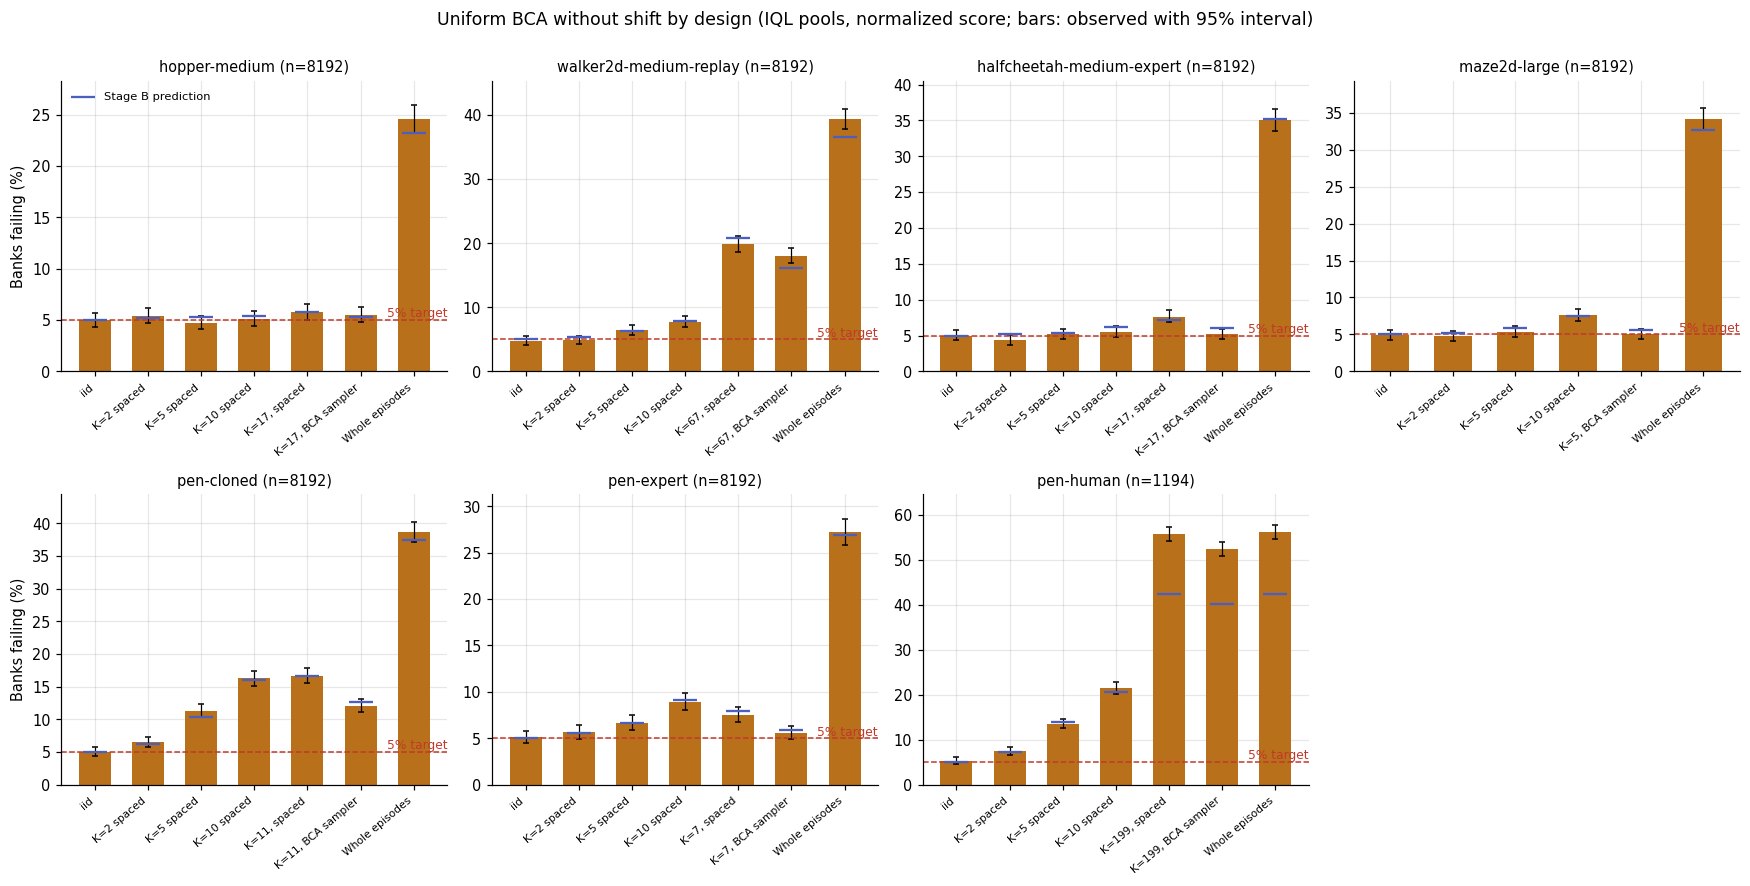

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
for ax, d in zip(axes.flat, DATASETS):
    e = R["datasets"][d]
    ds = [x for i, x in enumerate(designs(e)) if x[1] not in [y[1] for y in designs(e)[:i]]]  # configured K may repeat K=2/5/10
    x = np.arange(len(ds))
    arms = [arm(d, suffix) for _, suffix, _ in ds]
    ax.bar(x, [pct(a) for a in arms], 0.6, color=COL["BQ-CP"], yerr=yerr(arms), error_kw=dict(elinewidth=0.8, capsize=2))
    ax.scatter(x, [prediction(d, p)[0] for _, _, p in ds], marker="_", s=260, color=COL["pred"], zorder=3, label="Stage B prediction")
    target(ax)
    labels = [l.replace("Configured K", f"K={e['k']}").replace("Independent rows, large bank", f"iid n={e['big']}").replace("Independent rows", "iid") for l, _, _ in ds]
    ax.set_xticks(x, labels, fontsize=7, rotation=40, ha="right")
    ax.set_title(f"{SHORT[d]} (n={e['n']})", fontsize=9.5)
    top = np.nanmax([pct(a) for a in arms] + [prediction(d, p)[0] for _, _, p in ds] + [8])
    ax.set_ylim(0, min(100, top * 1.15))
axes[0, 0].set_ylabel("Banks failing (%)"); axes[1, 0].set_ylabel("Banks failing (%)"); axes[0, 0].legend(fontsize=7.5)
axes.flat[-1].axis("off")
fig.suptitle(f"Uniform BCA without shift by design ({R['name']} pools, normalized score; bars: observed with 95% interval)", y=1.0)
plt.tight_layout(); plt.show()

## 6. The configured bank

What IQL + BCA actually reserves on each dataset: n rows, K per withheld episode, drawn with BCA's own
sampler. BCA's sampler draws distinct episodes from a finite pool, so it is slightly optimistic when the bank
covers a large share of the pool; the spaced sampler draws with replacement and is slightly pessimistic.
Together they bracket deployment. `dependence_validated` is BCA's own flag (K ≤ 10 and at least 100
episodes).

In [7]:
rows = []
for d in DATASETS:
    e = R["datasets"][d]
    k, n = e["k"], e["n"]
    episodes = math.ceil(n / k)
    pool_eps = e["pool"]["rows"]["population_episodes"] if e["pool"] else None
    for s in SCORES:
        resv, spaced = arm(d, f"resv{k}", s=s), arm(d, f"strat{k}", s=s)
        p, D = prediction(d, f"{k} per episode, BCA reservation", s)
        ps, _ = prediction(d, f"{k} per episode, stratified", s)
        rows.append([SHORT[d], s, n, k, episodes, pool_eps, "yes" if (k <= 10 and episodes >= 100) else "no",
                     None if D is None or np.isnan(D) else round(D, 2), fail(resv), round(p, 1), fail(spaced), round(ps, 1),
                     fail(arm(d, f"resv{k}", "WBCP", s=s))])
display(table(rows, ["Dataset", "Score", "n", "K", "Episodes in bank", "Pool episodes", "dependence_validated", "D (MC, BCA sampler)",
                     "Uniform BCA, BCA sampler", "Predicted (%)", "Uniform BCA, spaced", "Predicted spaced (%)", "WBCP est. w, BCA sampler"]))

,Dataset,Score,n,K,Episodes in bank,Pool episodes,dependence_validated,"D (MC, BCA sampler)","Uniform BCA, BCA sampler",Predicted (%),"Uniform BCA, spaced",Predicted spaced (%),"WBCP est. w, BCA sampler"
0,hopper-medium,normalized,8192,17,482,1094,no,1.04,"5.5% [4.8, 6.3]",5.3,"5.8% [5.0, 6.5]",5.8,"5.7% [5.0, 6.4]"
1,hopper-medium,raw,8192,17,482,1094,no,1.07,"5.4% [4.7, 6.1]",5.6,"7.0% [6.3, 7.9]",6.6,"5.6% [4.9, 6.3]"
2,walker2d-medium-replay,normalized,8192,67,123,528,no,2.76,"18.1% [16.9, 19.3]",16.1,"19.9% [18.7, 21.2]",20.8,"20.3% [19.0, 21.6]"
3,walker2d-medium-replay,raw,8192,67,123,528,no,3.71,"25.1% [23.7, 26.4]",19.7,"23.7% [22.4, 25.0]",24.4,"26.8% [25.4, 28.2]"
4,halfcheetah-medium-expert,normalized,8192,17,482,1000,no,1.12,"5.2% [4.5, 5.9]",6.0,"7.6% [6.8, 8.5]",7.1,"6.0% [5.2, 6.7]"
5,halfcheetah-medium-expert,raw,8192,17,482,1000,no,1.15,"5.7% [5.0, 6.4]",6.3,"8.2% [7.4, 9.1]",8.2,"7.0% [6.2, 7.8]"
6,maze2d-large,normalized,8192,5,1639,8168,yes,1.07,"5.1% [4.4, 5.8]",5.6,"5.4% [4.7, 6.1]",5.9,"6.4% [5.7, 7.2]"
7,maze2d-large,raw,8192,5,1639,8168,yes,1.22,"6.0% [5.3, 6.8]",6.8,"7.8% [7.0, 8.7]",7.7,"7.3% [6.5, 8.2]"
8,pen-cloned,normalized,8192,11,745,1887,no,2.08,"12.1% [11.1, 13.2]",12.7,"16.7% [15.5, 17.9]",16.7,"19.7% [18.4, 20.9]"
9,pen-cloned,raw,8192,11,745,1887,no,2.14,"13.1% [12.1, 14.2]",13.0,"18.0% [16.8, 19.2]",17.2,"22.6% [21.3, 24.0]"


## 7. Distribution shift (K = 5 spaced)

Banks of K = 5 spaced rows per episode, with the test distribution tilted by exp(γ z): z is the closeness
of the logged action to the policy's (policy), the sparseness of the region (density) or the size of the
state (state). Uniform BCA ignores the shift; WBCP reweights the bank by estimated or exact density ratios.
The pre-registered expectation: uniform BCA fails badly under density and state tilts, WBCP fails more than
5% at the strongest tilts but far less than uniform BCA.

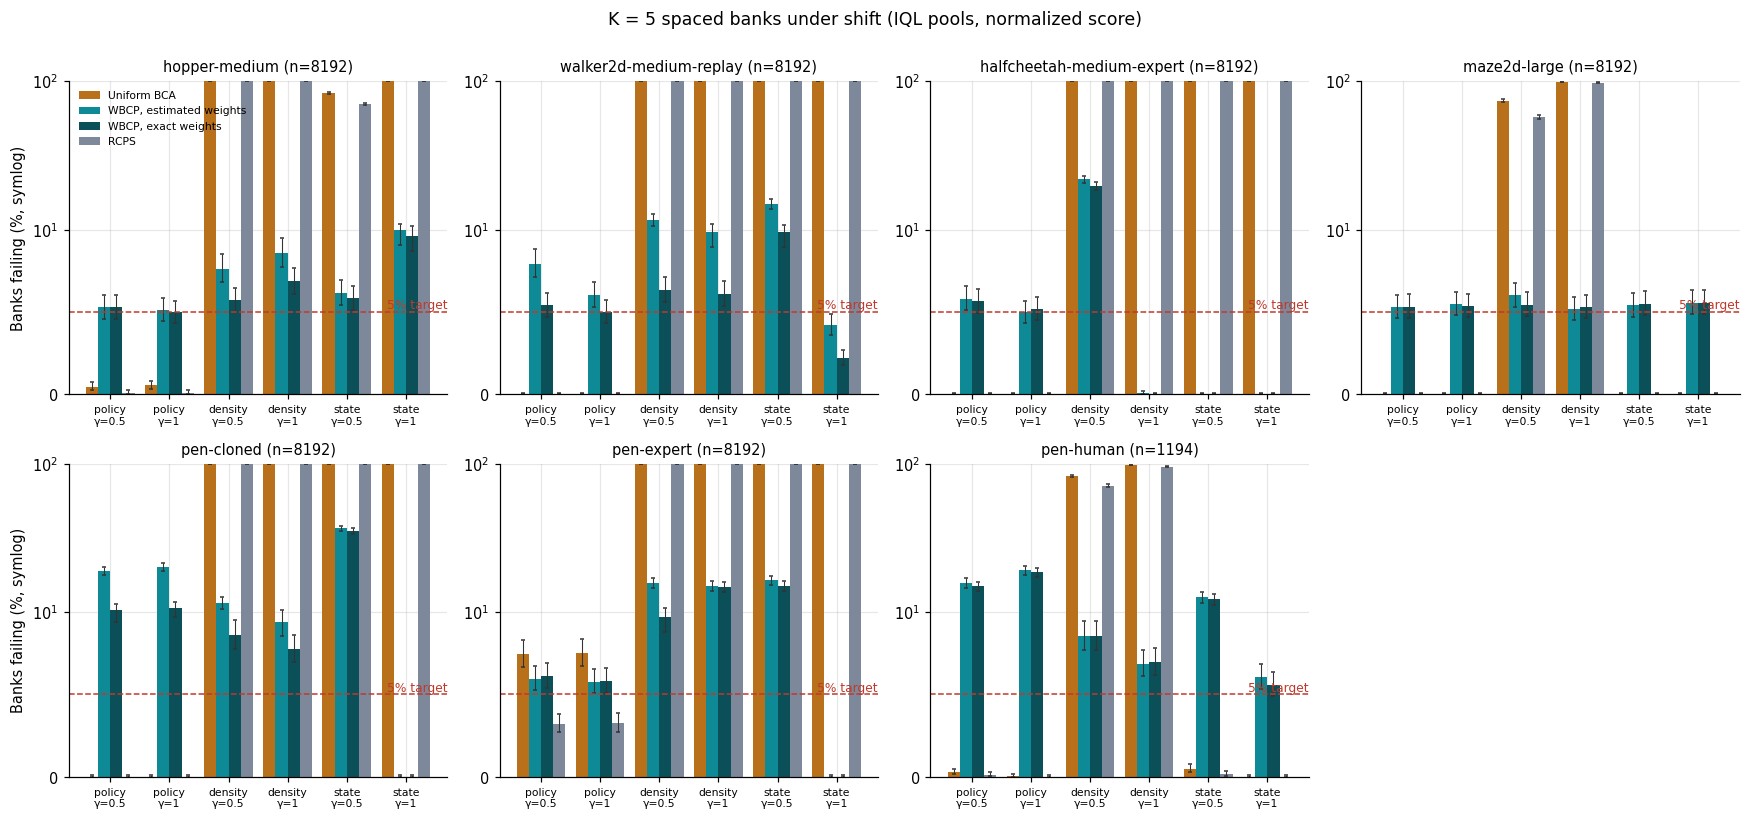

**K = 5 spaced under shift, normalized score**

,Dataset,Tilt,Calibration n_eff (exact w),Uniform BCA,"WBCP, estimated weights","WBCP, exact weights",RCPS,WBCP exact w: mean excess when failing (points)
0,hopper-medium,policy γ=0.5,7091,"0.5% [0.3, 0.7]","5.3% [4.6, 6.0]","5.3% [4.6, 6.0]","0.1% [0.0, 0.3]",0.16
1,hopper-medium,policy γ=1,5624,"0.6% [0.3, 0.8]","5.1% [4.4, 5.8]","5.0% [4.3, 5.7]","0.1% [0.0, 0.3]",0.18
2,hopper-medium,density γ=0.5,6360,"100.0% [99.9, 100.0]","7.6% [6.8, 8.5]","5.7% [5.0, 6.5]","100.0% [99.9, 100.0]",0.20
3,hopper-medium,density γ=1,2867,"100.0% [99.9, 100.0]","8.6% [7.7, 9.5]","6.9% [6.1, 7.7]","100.0% [99.9, 100.0]",0.35
4,hopper-medium,state γ=0.5,3877,"83.1% [81.9, 84.3]","6.1% [5.4, 6.9]","5.8% [5.1, 6.6]","70.3% [68.9, 71.7]",0.24
5,hopper-medium,state γ=1,269,"100.0% [99.9, 100.0]","10.0% [9.1, 11.0]","9.6% [8.7, 10.6]","100.0% [99.9, 100.0]",1.10
6,walker2d-medium-replay,policy γ=0.5,7002,"0.0% [0.0, 0.1]","7.9% [7.1, 8.8]","5.4% [4.7, 6.1]","0.0% [0.0, 0.1]",0.15
7,walker2d-medium-replay,policy γ=1,5315,"0.0% [0.0, 0.1]","6.1% [5.3, 6.8]","5.0% [4.3, 5.7]","0.0% [0.0, 0.1]",0.16
8,walker2d-medium-replay,density γ=0.5,6600,"100.0% [99.9, 100.0]","11.6% [10.6, 12.7]","6.4% [5.6, 7.2]","100.0% [99.9, 100.0]",0.21
9,walker2d-medium-replay,density γ=1,3950,"100.0% [99.9, 100.0]","9.9% [9.0, 10.8]","6.1% [5.4, 6.9]","100.0% [99.9, 100.0]",0.30


**K = 5 spaced under shift, raw score**

,Dataset,Tilt,Calibration n_eff (exact w),Uniform BCA,"WBCP, estimated weights","WBCP, exact weights",RCPS,WBCP exact w: mean excess when failing (points)
0,hopper-medium,policy γ=0.5,7091,"1.9% [1.5, 2.3]","5.0% [4.4, 5.7]","5.0% [4.3, 5.7]","0.6% [0.3, 0.8]",0.15
1,hopper-medium,policy γ=1,5624,"4.2% [3.6, 4.8]","4.9% [4.3, 5.6]","5.1% [4.4, 5.8]","1.4% [1.1, 1.8]",0.17
2,hopper-medium,density γ=0.5,6360,"100.0% [99.9, 100.0]","7.6% [6.7, 8.4]","6.1% [5.4, 6.9]","100.0% [99.9, 100.0]",0.18
3,hopper-medium,density γ=1,2867,"100.0% [99.9, 100.0]","8.9% [8.1, 9.9]","7.3% [6.5, 8.1]","100.0% [99.9, 100.0]",0.36
4,hopper-medium,state γ=0.5,3877,"2.4% [2.0, 3.0]","6.4% [5.6, 7.2]","6.4% [5.7, 7.2]","0.7% [0.5, 1.0]",0.22
5,hopper-medium,state γ=1,269,"98.8% [98.4, 99.1]","11.0% [10.0, 12.0]","10.7% [9.8, 11.7]","97.0% [96.4, 97.5]",1.09
6,walker2d-medium-replay,policy γ=0.5,7002,"0.0% [0.0, 0.1]","9.4% [8.5, 10.3]","6.1% [5.4, 6.9]","0.0% [0.0, 0.1]",0.16
7,walker2d-medium-replay,policy γ=1,5315,"0.0% [0.0, 0.1]","7.0% [6.3, 7.9]","5.2% [4.6, 6.0]","0.0% [0.0, 0.1]",0.19
8,walker2d-medium-replay,density γ=0.5,6600,"100.0% [99.9, 100.0]","14.3% [13.2, 15.4]","7.0% [6.2, 7.8]","100.0% [99.9, 100.0]",0.22
9,walker2d-medium-replay,density γ=1,3950,"100.0% [99.9, 100.0]","11.0% [10.0, 12.0]","6.7% [5.9, 7.5]","100.0% [99.9, 100.0]",0.30


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7.4))
k = len(ARMS)
w = 0.82 / k
x = np.arange(len(TILTS))
for ax, d in zip(axes.flat, DATASETS):
    for i, (a, name) in enumerate(ARMS.items()):
        arms = [arm(d, "strat5_shift", a, t, y) for t, y in TILTS]
        ax.bar(x - 0.41 + w * (i + 0.5), [pct(v) for v in arms], w, color=COL[a], label=name, yerr=yerr(arms),
               error_kw=dict(elinewidth=0.7, capsize=1.5, ecolor="#333"))
    target(ax)
    ax.set_yscale("symlog", linthresh=10); ax.set_ylim(0, 100)
    ax.set_xticks(x, [f"{t}\nγ={y:g}" for t, y in TILTS], fontsize=7)
    ax.set_title(f"{SHORT[d]} (n={R['datasets'][d]['n']})", fontsize=9.5)
axes[0, 0].set_ylabel("Banks failing (%, symlog)"); axes[1, 0].set_ylabel("Banks failing (%, symlog)")
axes.flat[-1].axis("off"); axes[0, 0].legend(fontsize=7, loc="upper left")
fig.suptitle(f"K = 5 spaced banks under shift ({R['name']} pools, normalized score)", y=1.0)
plt.tight_layout(); plt.show()

for s in SCORES:
    rows = []
    for d in DATASETS:
        for t, y in TILTS:
            b = block(d, "strat5_shift", t, y, s)
            if b is None:
                continue
            rows.append([SHORT[d], f"{t} γ={y:g}", round(b["ne"]), *[fail(b["A"].get(a)) for a in ARMS],
                         None if b["A"]["WBCP (oracle w)"].get("x") is None else round(100 * b["A"]["WBCP (oracle w)"]["x"], 2)])
    display(Markdown(f"**K = 5 spaced under shift, {s} score**"))
    display(table(rows, ["Dataset", "Tilt", "Calibration n_eff (exact w)", *ARMS.values(), "WBCP exact w: mean excess when failing (points)"]))

## 8. Estimated against exact weights

Without shift the exact weights are all 1, so any difference between WBCP with estimated weights and the
uniform rule is the cost of estimating weights that should be flat (from 1,000 + 1,000 rows, the benchmark's
default). On walker2d and pen-cloned this cost reached 15% failure at 8,192 rows (DEPENDENCE.md, Change 10),
because the score is not locally adaptive while the estimated weights vary with (s, a).

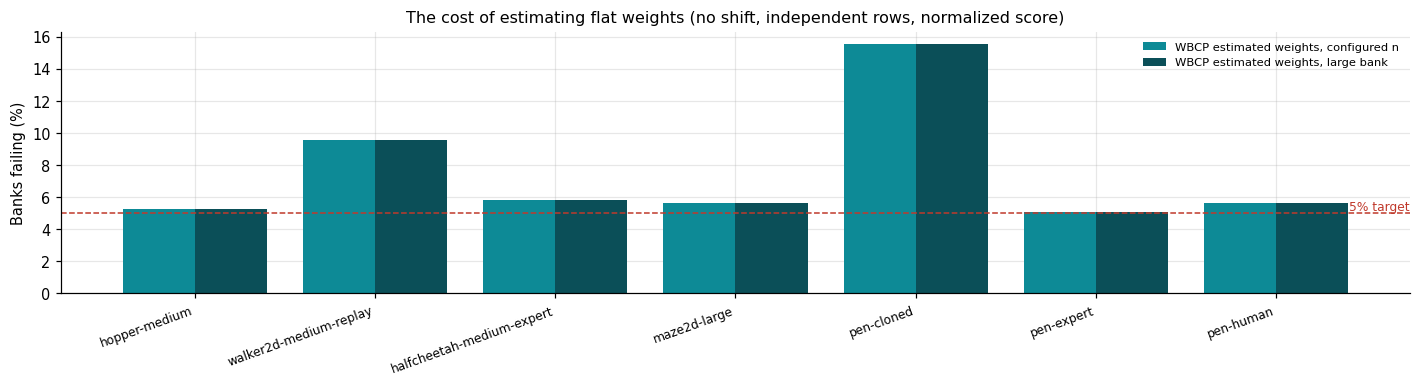

,Dataset,n,Score,Uniform BCA,"WBCP, estimated weights","WBCP, exact weights (= uniform)",Calibration n_eff (estimated w)
0,hopper-medium,8192,normalized,"5.0% [4.3, 5.7]","5.3% [4.6, 6.0]","5.0% [4.3, 5.7]",8176
1,hopper-medium,8192,raw,"5.4% [4.7, 6.2]","5.6% [4.9, 6.3]","5.5% [4.8, 6.2]",8176
2,walker2d-medium-replay,8192,normalized,"4.8% [4.2, 5.5]","9.6% [8.7, 10.5]","4.9% [4.2, 5.6]",8175
3,walker2d-medium-replay,8192,raw,"5.0% [4.3, 5.7]","11.9% [10.9, 12.9]","5.1% [4.4, 5.8]",8175
4,halfcheetah-medium-expert,8192,normalized,"5.0% [4.3, 5.7]","5.8% [5.1, 6.6]","5.0% [4.3, 5.7]",8175
5,halfcheetah-medium-expert,8192,raw,"5.3% [4.6, 6.0]","6.7% [6.0, 7.5]","5.2% [4.5, 5.9]",8175
6,maze2d-large,8192,normalized,"4.9% [4.3, 5.6]","5.6% [4.9, 6.4]","5.0% [4.3, 5.7]",8176
7,maze2d-large,8192,raw,"5.1% [4.4, 5.8]","6.0% [5.2, 6.7]","4.9% [4.3, 5.6]",8176
8,pen-cloned,8192,normalized,"5.0% [4.3, 5.7]","15.6% [14.4, 16.7]","5.0% [4.3, 5.7]",8173
9,pen-cloned,8192,raw,"4.7% [4.1, 5.4]","18.8% [17.6, 20.0]","4.7% [4.0, 5.3]",8173


In [9]:
rows = []
for d in DATASETS:
    e = R["datasets"][d]
    for suffix, n in (("iid", e["n"]), ("iid_big", e["big"])):
        if suffix == "iid_big" and e["n"] >= e["big"]:
            continue
        for s in SCORES:
            b = block(d, suffix, s=s)
            if b is None:
                rows.append([SHORT[d], n, s, "–", "–", "–", None])
                continue
            rows.append([SHORT[d], n, s, fail(b["A"]["BQ-CP"]), fail(b["A"]["WBCP"]), fail(b["A"]["WBCP (oracle w)"]), round(b["nh"])])
W = table(rows, ["Dataset", "n", "Score", "Uniform BCA", "WBCP, estimated weights", "WBCP, exact weights (= uniform)", "Calibration n_eff (estimated w)"])
fig, ax = plt.subplots(figsize=(13, 3.6))
sub = [(d, s) for d in DATASETS for s in ("normalized",)]
x = np.arange(len(DATASETS))
for i, (suffix, name, color) in enumerate((("iid", "configured n", "#0d8a96"), ("iid_big", "large bank", "#0b4f58"))):
    vals = [pct(arm(d, suffix if not (suffix == "iid_big" and R["datasets"][d]["n"] >= R["datasets"][d]["big"]) else "iid", "WBCP")) for d in DATASETS]
    ax.bar(x - 0.2 + 0.4 * i, vals, 0.4, color=color, label=f"WBCP estimated weights, {name}")
target(ax); ax.set_xticks(x, [SHORT[d] for d in DATASETS], rotation=20, ha="right", fontsize=8); ax.set_ylabel("Banks failing (%)")
ax.set_title("The cost of estimating flat weights (no shift, independent rows, normalized score)"); ax.legend(fontsize=7.5)
plt.tight_layout(); plt.show()
W

## 9. What a valid bank costs: threshold width

The mean certified threshold relative to λ\* (uniform BCA, no shift). A wider threshold is the price of
certifying with fewer effective rows; designs that fail are too narrow, not too wide.

In [10]:
rows = []
for d in DATASETS:
    e = R["datasets"][d]
    row = [SHORT[d]]
    for label in COLUMNS:
        match = [suffix for l, suffix, _ in designs(e) if l == label]
        b = block(d, match[0]) if match else None
        row.append(None if b is None or b["A"]["BQ-CP"]["th"] is None else round(100 * (b["A"]["BQ-CP"]["th"] / b["L"] - 1), 1))
    rows.append(row)
display(Markdown("**Mean threshold above λ\\* (%), uniform BCA, normalized score**"))
table(rows, ["Dataset"] + COLUMNS)

**Mean threshold above λ\* (%), uniform BCA, normalized score**

,Dataset,Independent rows,K=2 spaced,K=5 spaced,K=10 spaced,"Configured K, spaced","Configured K, BCA sampler",Whole episodes,"Independent rows, large bank"
0,hopper-medium,1.2,1.2,1.2,1.2,1.2,1.2,1.2,None
1,walker2d-medium-replay,2.2,2.3,2.2,2.2,2.3,2.0,1.9,None
2,halfcheetah-medium-expert,2.1,2.1,2.1,2.0,2.0,2.1,2.7,None
3,maze2d-large,2.1,2.1,2.1,2.1,2.1,2.1,2.0,None
4,pen-cloned,2.8,2.7,2.8,2.8,2.8,2.8,2.7,None
5,pen-expert,2.2,2.2,2.2,2.2,2.2,2.2,2.2,None
6,pen-human,2.2,2.3,2.4,2.6,-2.8,-0.1,-2.7,None


## 10. The same datasets under the other hosts

ρ and the configured bank's failure for every host whose pools exist so far (each host has its own
notebook). The dataset sets the episode structure; the host sets the score, through its critic and its
learned scale.

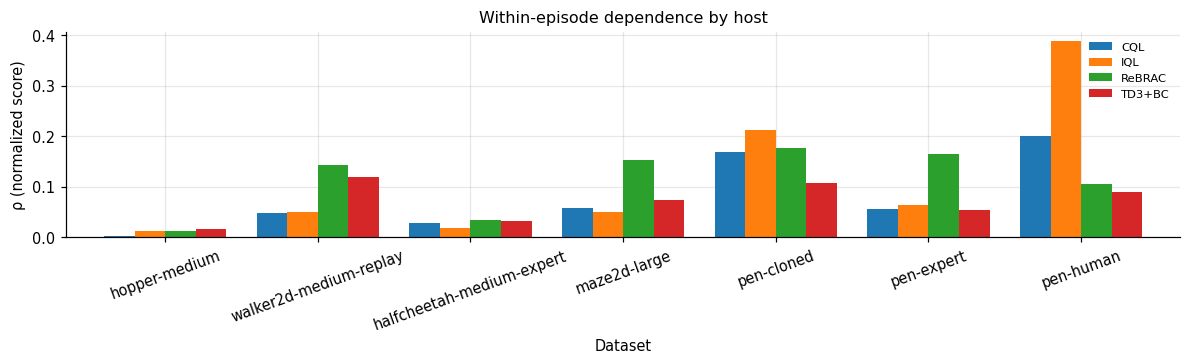

,Host,Dataset,ρ normalized,ρ raw,Bank n,K,"Configured bank, uniform BCA"
0,TD3+BC,hopper-medium,0.016,0.020,1024,6,–
1,TD3+BC,walker2d-medium-replay,0.120,0.109,1024,23,–
2,TD3+BC,halfcheetah-medium-expert,0.033,0.047,1024,6,–
3,TD3+BC,maze2d-large,0.073,0.095,1024,5,–
4,TD3+BC,pen-cloned,0.108,0.133,1024,5,–
5,TD3+BC,pen-expert,0.054,0.067,1024,5,–
6,TD3+BC,pen-human,0.090,0.179,248,124,–
7,ReBRAC,hopper-medium,0.012,0.012,1024,6,"4.3% [3.7, 5.0]"
8,ReBRAC,walker2d-medium-replay,0.143,0.140,1024,23,"18.3% [17.1, 19.5]"
9,ReBRAC,halfcheetah-medium-expert,0.034,0.040,1024,6,"5.3% [4.6, 6.0]"


In [11]:
rows = []
for h, name in HOSTS.items():
    other = R if h == HOST else load_results(h)
    for d in DATASETS:
        e = other["datasets"][d]
        if e["pred"] is None:
            continue
        k = e["k"]
        rows.append([name, SHORT[d], round(e["pred"]["scores"]["normalized"]["rho"], 3), round(e["pred"]["scores"]["raw"]["rho"], 3),
                     e["n"], k, fail(other_arm) if (other_arm := next((b["A"]["BQ-CP"] for b in (e["runs"].get(f"{P(d)}_resv{k}") or {"blocks": []})["blocks"]
                                                                       if b["s"] == "normalized" and b["y"] == 0), None)) else "–"])
X = table(rows, ["Host", "Dataset", "ρ normalized", "ρ raw", "Bank n", "K", "Configured bank, uniform BCA"])
if len(X):
    piv = X.pivot(index="Dataset", columns="Host", values="ρ normalized").reindex([SHORT[d] for d in DATASETS])
    fig, ax = plt.subplots(figsize=(11, 3.4))
    piv.plot.bar(ax=ax, rot=20, width=0.8)
    ax.set_ylabel("ρ (normalized score)"); ax.set_title("Within-episode dependence by host"); ax.legend(fontsize=7.5)
    plt.tight_layout(); plt.show()
X

## 11. All results

Every result block of this host's matrix (and any other run on its pools): one row per run, tilt and
score, with each rule's failure and 95% interval, and WBCP's (estimated weights) mean risk, percentiles,
excess when failing, threshold and abstention.

In [12]:
rows = []
for d in DATASETS:
    e = R["datasets"][d]
    for name, run in list(e["runs"].items()) + list(e["extra"].items()):
        for b in run["blocks"]:
            w = b["A"].get("WBCP", {})
            rows.append([SHORT[d], name, run.get("label", "outside the matrix"), b["n"], "none" if b["y"] == 0 else b["t"], b["y"], b["s"],
                         round(b["L"], 3), round(b["ne"]), round(b["cs"]), *[fail(b["A"].get(a)) for a in ARMS],
                         None if w.get("r") is None else round(100 * w["r"], 2), None if w.get("q95") is None else round(100 * w["q95"], 2),
                         None if w.get("q99") is None else round(100 * w["q99"], 2), None if w.get("x") is None else round(100 * w["x"], 2),
                         None if w.get("th") is None else round(w["th"], 3), None if w.get("ab") is None else round(100 * w["ab"], 1)])
ALLR = table(rows, ["Dataset", "Run", "Design", "n", "Tilt", "γ", "Score", "λ*", "n_eff", "Mean bank size", *ARMS.values(),
                    "WBCP mean risk (%)", "WBCP q95 (%)", "WBCP q99 (%)", "WBCP excess | fail", "WBCP threshold", "WBCP abstain (%)"])
print(f"{len(ALLR)} result blocks")
ALLR

180 result blocks


,Dataset,Run,Design,n,Tilt,γ,Score,λ*,n_eff,Mean bank size,Uniform BCA,"WBCP, estimated weights","WBCP, exact weights",RCPS,WBCP mean risk (%),WBCP q95 (%),WBCP q99 (%),WBCP excess | fail,WBCP threshold,WBCP abstain (%)
0,hopper-medium,hopper_iid,Independent rows,8192,none,0.0,normalized,0.796,8192,8192,"5.0% [4.3, 5.7]","5.3% [4.6, 6.0]","5.0% [4.3, 5.7]","1.9% [1.5, 2.4]",9.46,10.01,10.26,0.15,0.806,0.0
1,hopper-medium,hopper_iid,Independent rows,8192,none,0.0,raw,0.724,8192,8192,"5.4% [4.7, 6.2]","5.6% [4.9, 6.3]","5.5% [4.8, 6.2]","1.9% [1.5, 2.4]",9.46,10.01,10.27,0.14,0.735,0.0
2,hopper-medium,hopper_strat2,K=2 spaced,8192,none,0.0,normalized,0.796,8192,8192,"5.4% [4.7, 6.2]","5.3% [4.6, 6.0]","5.3% [4.6, 6.0]","1.9% [1.5, 2.3]",9.45,10.01,10.25,0.15,0.806,0.0
3,hopper-medium,hopper_strat2,K=2 spaced,8192,none,0.0,raw,0.724,8192,8192,"5.2% [4.5, 5.9]","5.3% [4.6, 6.0]","5.4% [4.7, 6.1]","2.2% [1.8, 2.7]",9.46,10.01,10.22,0.14,0.735,0.0
4,hopper-medium,hopper_strat5,K=5 spaced,8192,none,0.0,normalized,0.796,8192,8192,"4.7% [4.1, 5.4]","5.2% [4.5, 5.9]","4.8% [4.1, 5.5]","1.7% [1.3, 2.1]",9.45,10.00,10.23,0.14,0.806,0.0
5,hopper-medium,hopper_strat5,K=5 spaced,8192,none,0.0,raw,0.724,8192,8192,"4.9% [4.3, 5.6]","5.2% [4.5, 5.9]","5.1% [4.4, 5.8]","1.9% [1.5, 2.4]",9.46,10.00,10.22,0.14,0.735,0.0
6,hopper-medium,hopper_strat10,K=10 spaced,8192,none,0.0,normalized,0.796,8192,8192,"5.1% [4.5, 5.9]","5.2% [4.5, 5.9]","5.1% [4.4, 5.8]","1.7% [1.3, 2.2]",9.45,10.00,10.22,0.14,0.806,0.0
7,hopper-medium,hopper_strat10,K=10 spaced,8192,none,0.0,raw,0.724,8192,8192,"5.5% [4.8, 6.2]","5.5% [4.8, 6.3]","5.8% [5.1, 6.5]","2.1% [1.7, 2.6]",9.46,10.02,10.26,0.14,0.735,0.0
8,hopper-medium,hopper_blocks,Whole episodes,8192,none,0.0,normalized,0.796,8433,8433,"24.6% [23.2, 25.9]","24.5% [23.1, 25.8]","24.8% [23.5, 26.2]","18.3% [17.1, 19.5]",9.48,10.59,11.02,0.37,0.806,0.0
9,hopper-medium,hopper_blocks,Whole episodes,8192,none,0.0,raw,0.724,8433,8433,"29.0% [27.6, 30.4]","28.6% [27.2, 30.0]","29.2% [27.7, 30.6]","22.5% [21.2, 23.9]",9.50,10.83,11.34,0.48,0.734,0.0


## 12. Provenance

Score pools (with the SHA-256 of their arrays), the run files and the commands that made them. Every run
is reproducible from `python experiments/wbcp/host_matrix.py --host iql --stage {freeze,predict,bench}`.

In [13]:
display(table([[SHORT[d], e["pool"]["dir"] if e["pool"] else "–", e["pool"]["algorithm"] if e["pool"] else "–",
                 e["pool"]["device"] if e["pool"] else "–", e["pool"]["npz_sha256"] if e["pool"] else "–",
                 e["pred"]["created"] if e["pred"] else "–"]
                for d, e in R["datasets"].items()], ["Dataset", "Score pool", "Host", "Trained on", "frozen.npz SHA-256", "Predictions created"]))
rows = []
for d, e in R["datasets"].items():
    for name, run in e["runs"].items():
        s = run["settings"]
        rows.append([SHORT[d], name, run["file"], s["trials"], s["seed"], s["n"], s.get("per_episode"), s.get("spacing"), s.get("blocks")])
    for name in e["missing"]:
        rows.append([SHORT[d], name, "not run yet", None, None, None, None, None, None])
table(rows, ["Dataset", "Run", "File", "Trials", "Seed", "n", "K", "Sampler", "Whole episodes"])

,Dataset,Score pool,Host,Trained on,frozen.npz SHA-256,Predictions created
0,hopper-medium,runs/wbcp_frozen/iql-hopper-s202609171-u100000,iql,cpu,bde56af94b7d52f45c3bf763094debb2a85654f9439b79dfd64c34ca07dd7775,2026-10-02T02:04:20.700805+00:00
1,walker2d-medium-replay,runs/wbcp_frozen/iql-walker2d-s202609171-u100000,iql,cpu,094628b074cb60c0354f7992db57b59aac1b4cf94a32c7c948471d96f65d9829,2026-10-02T02:14:47.870357+00:00
2,halfcheetah-medium-expert,runs/wbcp_frozen/iql-halfcheetah-s202609171-u100000,iql,cpu,78b07b76aee7023994bca6c1275bc52fa7864513b3af652e10cb46442b0e5023,2026-10-02T02:20:46.799223+00:00
3,maze2d-large,runs/wbcp_frozen/iql-maze2d-s202609171-u100000,iql,cpu,31ce96e2ba2687a547d2659b3073332159edcfc7d2da71d0249544b89588593e,2026-10-02T02:31:11.076885+00:00
4,pen-cloned,runs/wbcp_frozen/iql-pen-cloned-s202609171-u100000,iql,cpu,a67a103df131b5752577a76fdcbff4a8cbac563895fb8677660e5b954021b19f,2026-10-02T02:52:20.795547+00:00
5,pen-expert,runs/wbcp_frozen/iql-pen-expert-s202609171-u100000,iql,cpu,a42bdc5cff5d87688ed46802687bc90cd0ac6819807e09da283003bc054ca746,2026-10-02T03:02:57.270243+00:00
6,pen-human,runs/wbcp_frozen/iql-pen-human-s202609171-u100000,iql,cpu,79035ceb385267a891c0804203b2482d474d1c8a4946440ae916487040bd2ee9,2026-10-02T03:10:35.878912+00:00


,Dataset,Run,File,Trials,Seed,n,K,Sampler,Whole episodes
0,hopper-medium,hopper_iid,runs/wbcp_hosts/iql/hopper_iid.json,4000,2026093001,[8192],NaN,random,False
1,hopper-medium,hopper_strat2,runs/wbcp_hosts/iql/hopper_strat2.json,4000,2026093001,[8192],2.0,stratified,False
2,hopper-medium,hopper_strat5,runs/wbcp_hosts/iql/hopper_strat5.json,4000,2026093001,[8192],5.0,stratified,False
3,hopper-medium,hopper_strat10,runs/wbcp_hosts/iql/hopper_strat10.json,4000,2026093001,[8192],10.0,stratified,False
4,hopper-medium,hopper_blocks,runs/wbcp_hosts/iql/hopper_blocks.json,4000,2026093001,[8192],NaN,random,True
5,hopper-medium,hopper_resv17,runs/wbcp_hosts/iql/hopper_resv17.json,4000,2026093001,[8192],17.0,reservation,False
6,hopper-medium,hopper_strat17,runs/wbcp_hosts/iql/hopper_strat17.json,4000,2026093001,[8192],17.0,stratified,False
7,hopper-medium,hopper_strat5_shift,runs/wbcp_hosts/iql/hopper_strat5_shift.json,4000,2026093002,[8192],5.0,stratified,False
8,walker2d-medium-replay,walker2d_iid,runs/wbcp_hosts/iql/walker2d_iid.json,4000,2026093001,[8192],NaN,random,False
9,walker2d-medium-replay,walker2d_strat2,runs/wbcp_hosts/iql/walker2d_strat2.json,4000,2026093001,[8192],2.0,stratified,False
